In [439]:
import os
import re
import pandas as pd
import numpy as np
import csv
import math
from pathlib import Path
import datetime as dt
import matplotlib.pyplot as plt
from scipy.stats import norm
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

## Data

In [484]:
samp1 = pd.read_csv('../notebooks/data/SPXW_exp2026-04-06_2026-03-30_14-28-29.csv', header=0)
samp2 = pd.read_csv('../notebooks/data/SPXW_exp2026-04-06_2026-03-31_14-08-49.csv', header=0)

In [433]:
current_spot = samp1.head(1)['underlying_price'].values[0]
current_spot

np.float64(6318.89)

In [450]:
calls_samp1 = samp1.loc[samp1['contract_type'] == 'CALL'].reset_index(drop=True)
puts_samp1 = samp1.loc[samp1['contract_type'] == 'PUT'].reset_index(drop=True)
call_strikes = samp1.loc[samp1['contract_type'] == 'CALL']['strike'].tolist()
put_strikes = samp1.loc[samp1['contract_type'] == 'PUT']['strike'].tolist()

## Find an Iron Condor

In [464]:
call_legs = samp1.loc[(samp1['delta'] < 0.06) & (samp1['delta'] >= 0.04) & (samp1['contract_type'] == 'CALL')]
call_legs[['description', 'mark', 'bid', 'ask', 'delta', 'gamma', 'theta', 'vega','rho', 'volatility']]

,description,mark,bid,ask,delta,gamma,theta,vega,rho,volatility
154,SPXW 04/06/2026 6630.00 C,4.45,4.40,4.5,0.056,0.001,-1.433,0.995,0.068,21.609
155,SPXW 04/06/2026 6635.00 C,4.10,4.00,4.2,0.052,0.001,-1.336,0.938,0.063,21.460
156,SPXW 04/06/2026 6640.00 C,3.80,3.70,3.9,0.049,0.001,-1.262,0.892,0.059,21.390
157,SPXW 04/06/2026 6645.00 C,3.50,3.40,3.6,0.046,0.001,-1.199,0.852,0.056,21.361
158,SPXW 04/06/2026 6650.00 C,3.30,3.20,3.4,0.044,0.000,-1.134,0.811,0.052,21.317
159,SPXW 04/06/2026 6655.00 C,3.03,2.95,3.1,0.041,0.000,-1.061,0.765,0.049,21.219


In [449]:
put_legs = samp1.loc[(samp1['delta'] >= -0.06) & (samp1['delta'] <  -0.03) & (samp1['contract_type'] == 'PUT')]
put_legs[['description', 'mark', 'bid', 'ask', 'delta', 'gamma', 'theta', 'vega','rho', 'volatility']]

,description,mark,bid,ask,delta,gamma,theta,vega,rho,volatility
258,SPXW 04/06/2026 5750.00 P,4.20,4.1,4.3,-0.032,0.0,-1.533,0.633,-0.040,37.316
259,SPXW 04/06/2026 5775.00 P,4.60,4.5,4.7,-0.035,0.0,-1.608,0.678,-0.043,36.339
260,SPXW 04/06/2026 5800.00 P,5.00,4.9,5.1,-0.039,0.0,-1.707,0.733,-0.048,35.454
261,SPXW 04/06/2026 5825.00 P,5.40,5.3,5.5,-0.043,0.0,-1.827,0.799,-0.053,34.637
262,SPXW 04/06/2026 5850.00 P,6.00,5.9,6.1,-0.048,0.0,-1.966,0.873,-0.059,33.857
263,SPXW 04/06/2026 5875.00 P,6.65,6.5,6.8,-0.053,0.0,-2.096,0.949,-0.066,32.994
264,SPXW 04/06/2026 5900.00 P,7.45,7.3,7.6,-0.060,0.0,-2.263,1.041,-0.074,32.249


In [452]:
# NOTE: example iron condor for EV calculations
long_put_strike = 5850.0
short_put_strike = 5875.0
short_call_strike = 6630.0
long_call_strike = 6655.0

## EV Estimate using Max Loss

In [457]:
def calc_ic_price(short_call, long_call, short_put, long_put):
    return (short_call['mark'].values[0] - long_call['mark'].values[0]).round(2) + \
        (short_put['mark'].values[0] - long_put['mark'].values[0]).round(2)

In [458]:
short_call = samp1.loc[(samp1['contract_type'] == 'CALL') & (samp1['strike'] == short_call_strike)]
long_call = samp1.loc[(samp1['contract_type'] == 'CALL') & (samp1['strike'] == long_call_strike)]
short_put = samp1.loc[(samp1['contract_type'] == 'PUT') & (samp1['strike'] == short_put_strike)]
long_put = samp1.loc[(samp1['contract_type'] == 'PUT') & (samp1['strike'] == long_put_strike)]

credit = calc_ic_price(short_call, long_call, short_put, long_put)
print('credit received: ', credit)

credit received:  2.07


In [459]:
p_win = 1.0 - long_call['delta'].values[0] + long_put['delta'].values[0]
p_max_loss = 1.0 - p_win

In [460]:
# NOTE: 25 point spreads
naive_ev = p_win * credit + p_max_loss * -25
print(naive_ev)

-0.33923000000000214


## EV Estimate using Stop Loss

$$
EV = P(\text{safe}) \cdot \text{credit}
+ P(\text{up stop}) \cdot (\text{credit} - \text{exit price}_{up})
+ P(\text{down stop}) \cdot (\text{credit} - \text{exit price}_{down})
$$

In [465]:
STOP_LOSS_MULT = 2.5

In [137]:
def calc_ev_crude(credit, p_stop_up, p_stop_down, exit_stop_up, exit_stop_down):
    p_win = 1.0 - abs(p_stop_up) - abs(p_stop_down)
    ev = credit * p_win - p_stop_up * (credit - exit_stop_up) - p_stop_down * (credit - exit_stop_down)
    return p_win, ev

In [86]:
def find_strike(target, strikes):
    if target in strikes:
        return target
    else:
        return min(strikes, key=lambda x: abs(x - target))

In [106]:
def find_stop_loss_strike(step, opt_chain, long_put_strike, short_put_strike, short_call_strike, long_call_strike, verbose=False):
    result = {}
    short_call = samp1.loc[(samp1['contract_type'] == 'CALL') & (samp1['strike'] == short_call_strike)]
    long_call = samp1.loc[(samp1['contract_type'] == 'CALL') & (samp1['strike'] == long_call_strike)]
    short_put = samp1.loc[(samp1['contract_type'] == 'PUT') & (samp1['strike'] == short_put_strike)]
    long_put = samp1.loc[(samp1['contract_type'] == 'PUT') & (samp1['strike'] == long_put_strike)]
    
    credit = (short_call['mark'].values[0] - long_call['mark'].values[0]) + (short_put['mark'].values[0] - long_put['mark'].values[0])
    result['credit'] = credit.round(2)

    for _ in range(0, 100):
        short_call_strike = find_strike(short_call_strike + step, call_strikes)
        long_call_strike = find_strike(long_call_strike + step, call_strikes)
        long_put_strike = find_strike(long_put_strike + step, put_strikes)
        short_put_strike = find_strike(short_put_strike + step, put_strikes)
    
        short_call = samp1.loc[(opt_chain['contract_type'] == 'CALL') & (opt_chain['strike'] == short_call_strike)]
        long_call = samp1.loc[(opt_chain['contract_type'] == 'CALL') & (opt_chain['strike'] == long_call_strike)]
        short_put = samp1.loc[(opt_chain['contract_type'] == 'PUT') & (opt_chain['strike'] == short_put_strike)]
        long_put = samp1.loc[(opt_chain['contract_type'] == 'PUT') & (opt_chain['strike'] == long_put_strike)]
    
        short_call_delta = short_call['delta'].values[0].round(4)
        long_call_delta = long_call['delta'].values[0].round(4)
        short_put_delta = short_put['delta'].values[0].round(4)
        long_put_delta = long_put['delta'].values[0].round(4)
    
        ic_price = (short_call['mark'].values[0] - long_call['mark'].values[0]) + (short_put['mark'].values[0] - long_put['mark'].values[0])

        if verbose:
            print(f'ic_price: {ic_price}')
            
            print(f'short call: {short_call_strike} / delta: {short_call_delta}')
            print(f'long call: {long_call_strike} / detla: {long_call_delta}')
        
            print(f'short put: {short_put_strike} / delta: {short_put_delta}')
            print(f'long put: {long_put_strike} / delta: {long_put_delta}')
        
            print('---')
    
        if ic_price >= STOP_LOSS_MULT * credit.round(2):
            result['ic_price'] = ic_price.round(2)
            result['short_call_strike'] = short_call_strike
            result['short_call_delta'] = short_call_delta

            result['long_call_strike'] = long_call_strike
            result['long_call_delta'] = long_call_delta

            result['short_put_strike'] = short_put_strike
            result['short_put_delta'] = short_put_delta

            result['long_put_strike'] = long_put_strike
            result['long_put_delta'] = long_put_delta
            
            return result

    return result


In [110]:
def print_result(result):
    print(f"credit: {result['credit']}")
    print(f"stop loss exit price: {result['ic_price']}")
    print(f"short_call: {result['short_call_strike']} / delta: {result['short_call_delta']}")
    print(f"short_put: {result['short_put_strike']} / delta: {result['short_put_delta']}")
    print(f"long_call: {result['long_call_strike']} / delta: {result['long_call_delta']}")
    print(f"long_put: {result['long_put_strike']} / delta: {result['long_put_delta']}")

In [141]:
# NOTE: move down result - a little confusing we move the iron condor down in order to simulate the stop loss 
# triggered by a move up.
step = -25

mv_down_result = find_stop_loss_strike(
    step, 
    samp1, 
    long_put_strike, 
    short_put_strike, 
    short_call_strike, 
    long_call_strike
)

print_result(mv_down_result)

credit: 2.07
stop loss exit price: 5.4
short_call: 6505.0 / delta: 0.193
short_put: 5750.0 / delta: -0.032
long_call: 6530.0 / delta: 0.158
long_put: 5725.0 / delta: -0.03


In [136]:
# NOTE: move up - again confusing because we move the iron condor up to simulate
# a stop loss triggered by a move down
step = 25
long_put_strike = 5850.0
short_put_strike = 5875.0
short_call_strike = 6630.0
long_call_strike = 6655.0

mv_up_result = find_stop_loss_strike(
    step, 
    samp1, 
    long_put_strike, 
    short_put_strike, 
    short_call_strike, 
    long_call_strike
)

print_result(mv_up_result)

credit: 2.07
stop loss exit price: 5.55
short_call: 6925.0 / delta: 0.002
short_put: 6175.0 / delta: -0.261
long_call: 6950.0 / delta: 0.002
long_put: 6150.0 / delta: -0.229


In [138]:
p_win, ev_crude = calc_ev_crude(
    mv_down_result['credit'],
    mv_down_result['short_call_delta'],
    mv_up_result['short_put_delta'],
    mv_down_result['ic_price'],
    mv_up_result['ic_price']
)
print('p_win: ', p_win.round(2))
print('ev: ', ev_crude)

p_win:  0.55
ev:  0.86463


## Build IV Model

IV is modeled as a quadratic in moneyness with time interaction terms. 
```
IV ≈ a + b*x + c*x^2 + d*τ + e*(x*τ) + f*(x^2*τ)

x_new = np.log(strike / new_spot)
τ_new = time_to_expiration

iv = (
    a
    + b * x_new
    + c * x_new**2
    + d * τ_new
    + e * (x_new * τ_new)
    + f * (x_new**2 * τ_new)
)
```

In [442]:
DATA_DIR = os.path.expanduser("~/.tickrake/data/options/schwab")
# NOTE: only use the option chain samples prior to the above option chain used to select the iron condor
CUTOFF = dt.datetime.strptime("2026-03-30_14-28-29", "%Y-%m-%d_%H-%M-%S")
pattern = re.compile(r"SPXW_exp(\d{4}-\d{2}-\d{2})_(\d{4}-\d{2}-\d{2})_(\d{2}-\d{2}-\d{2})\.csv")

rows = []
sample_cnt = 0

for root, _, files in os.walk(DATA_DIR):
    for file in files:
        match = pattern.match(file)
        if not match:
            continue

        exp_date_str, sample_date_str, sample_time_str = match.groups()

        sample_dt = dt.datetime.strptime(
            f"{sample_date_str}_{sample_time_str}",
            "%Y-%m-%d_%H-%M-%S"
        )

        if sample_dt >= CUTOFF:
            continue

        sample_cnt += 1
        exp_dt = dt.datetime.strptime(exp_date_str, "%Y-%m-%d") + dt.timedelta(hours=16)

        tau = (exp_dt - sample_dt).total_seconds() / (365 * 24 * 60 * 60)
        if tau <= 0:
            continue

        path = os.path.join(root, file)

        try:
            df = pd.read_csv(path)
        except Exception:
            continue

        df = df.dropna(subset=["volatility", "strike", "underlying_price", "contract_type"])
        df = df[df["volatility"] > 0]

        # NOTE: option filter
        is_call = df["contract_type"] == "CALL"
        is_put  = df["contract_type"] == "PUT"
        
        spot = df["underlying_price"]

        # NOTE: include some, but not all ITM strikes to capture the curvature
        df = df[
            (is_call & (df["strike"] > spot*0.95)) | 
            (is_put  & (df["strike"] < spot*1.09))
        ]

        iv = df["volatility"].values
        spot = df["underlying_price"].values
        strike = df["strike"].values
        contract_type = df["contract_type"].values

        x = np.log(strike / spot)

        for xi, iv_i, ct in zip(x, iv, contract_type):
            rows.append((xi, tau, iv_i, ct))

print('Option chain sample count: ', sample_cnt)

data = pd.DataFrame(rows, columns=["x", "tau", "iv", "contract_type"])

# NOTE: feature set
# - strike price - for baseline moneyness
# - strike squared - captures the curvature of IV surface
# - time to expiration - captures how IV changes with time
# - time to expiration times strike - captures how IV skew changes with time
data["x2"] = data["x"] ** 2
data["x_tau"] = data["x"] * data["tau"]
data["x2_tau"] = data["x2"] * data["tau"]

feat_cols = ["x", "x2", "tau", "x_tau", "x2_tau"]

calls = data[data["contract_type"] == "CALL"].reset_index(drop=True)
puts  = data[data["contract_type"] == "PUT"].reset_index(drop=True)

def fit_surface(df):
    X = df[feat_cols]
    y = df["iv"]

    model = LinearRegression()
    model.fit(X, y)
    return model

# NOTE: fit separate surfaces for calls and puts
model_call = fit_surface(calls)
model_put  = fit_surface(puts)

def print_model(name, model):
    print(f"\n{name} model:")
    for fname, coef in zip(FEATURES, model.coef_):
        print(f"{fname}: {coef:.6f}")
    print("intercept:", model.intercept_)

print_model("CALL", model_call)
print_model("PUT", model_put)

sample cnt:  9389

CALL model:
x: 279.835059
x2: 1426.647294
tau: -781.857450
x_tau: -11256.013612
x2_tau: -42041.956016
intercept: 34.80935440071303

PUT model:
x: -627.349453
x2: 204.647442
tau: -962.304709
x_tau: 19013.528556
x2_tau: -8004.965300
intercept: 39.29254574615485


In [443]:
def iv_from_surface_model(strike, spot, tau, model):
    x = np.log(strike / spot)

    X = pd.DataFrame([{
        "x": x,
        "x2": x**2,
        "tau": tau,
        "x_tau": x * tau,
        "x2_tau": (x**2) * tau
    }])

    iv = model.predict(X)[0]

    return iv

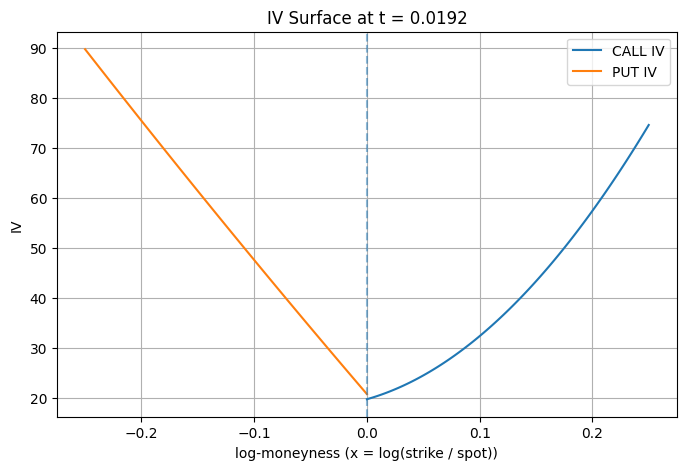

In [446]:
# NOTE: Quick check to make sure the vol surface looks sane.
# Expecting a steeper put surface and more curved call surface.
tau = 7 / 365
spot = 100

x_put = np.linspace(-0.25, 0.0, 100)
x_call = np.linspace(0.0, 0.25, 100)

put_ivs = []
call_ivs = []

for x in x_put:
    strike = spot * np.exp(x)
    put_ivs.append(
        iv_from_surface_model(strike, spot, tau, model_put)
    )

for x in x_call:
    strike = spot * np.exp(x)
    call_ivs.append(
        iv_from_surface_model(strike, spot, tau, model_call)
    )

plt.figure(figsize=(8, 5))
plt.plot(x_call, call_ivs, label="CALL IV")
plt.plot(x_put, put_ivs, label="PUT IV")
plt.axvline(0, linestyle="--", alpha=0.5)

plt.xlabel("log-moneyness (x = log(strike / spot))")
plt.ylabel("IV")
plt.title(f"IV Surface at t = {tau:.4f}")
plt.legend()
plt.grid(True)
plt.show()

## EV Estimate using Modeled IV Surface

Now reprice the iron condor at each step using the above time and moneyness dependent IV surface rather than the static option chain.

### Notes for Calculations
Assuming European option under Black–Scholes:

Call option:
$$
C = S \cdot N(d_1) - K \cdot e^{-rT} \cdot N(d_2)
$$

Put option:
$$
P = K \cdot e^{-rT} \cdot N(-d_2) - S \cdot N(-d_1)
$$

where:
$$
d_1 = \frac{\ln(S/K) + (r + \tfrac{1}{2}\sigma^2)T}{\sigma \sqrt{T}}
$$
$$
d_2 = d_1 - \sigma \sqrt{T}
$$

Variables:
- S: spot price
- K: strike
- T: time to expiration (in years)
- r: risk-free rate
- $\sigma$: implied volatility
- $N(\cdot)$: standard normal CDF

In [479]:
def price_iron_condor(spot, t, r, legs, iv_params):
    total = 0.0
    delta_total = 0.0

    for leg in legs:
        strike = leg["strike"]
        qty = leg["qty"]
        opt_type = leg["type"]
        
        model = iv_params[opt_type]
        iv = iv_from_surface_model(strike, spot, t, model)
        vol = iv / 100.0

        # NOTE: calculate delta with the new vol
        if qty < 0 and opt_type == 'CALL':
            d1 = (np.log(spot / strike) + (r + 0.5 * vol**2) * t) / (vol * np.sqrt(t))
            delta = norm.cdf(d1)
            short_call_delta = np.where(spot > strike, 1.0, 0.0)
            short_call_delta = np.where(t <= 0, short_call_delta, delta)
        elif qty < 0 and opt_type == 'PUT':
            d1 = (np.log(spot / strike) + (r + 0.5 * vol**2) * t) / (vol * np.sqrt(t))
            delta = norm.cdf(d1) - 1.0
            short_put_delta = np.where(spot < strike, -1.0, 0.0)
            short_put_delta = np.where(t <= 0, short_put_delta, delta)
                
        # NOTE: calculate price with the new vol
        d1 = (np.log(spot / strike) + (r + 0.5 * vol**2) * t) / (vol * np.sqrt(t))
        d2 = d1 - vol * np.sqrt(t)
    
        if opt_type == "CALL":
            price = spot * norm.cdf(d1) - strike * np.exp(-r * t) * norm.cdf(d2)
            intrinsic = np.maximum(spot - strike, 0.0)
        else:
            price = strike * np.exp(-r * t) * norm.cdf(-d2) - spot * norm.cdf(-d1)
            intrinsic = np.maximum(strike - spot, 0.0)
    
        price = np.where(t <= 0, intrinsic, price)

        # print(f'{opt_type} / {strike} / {qty} / {vol} / {price}')
        
        total += qty * price
    
    return abs(total), short_call_delta, short_put_delta

def simulate_path(
    spot0,
    t0,
    r,
    legs,
    iv_params,
    credit,
    stop_multiple=2.0,
    n_steps=50,
    step = 25
):
    spots_up = spot0 + step * np.arange(1, n_steps + 1)
    spots_down = spot0 - step * np.arange(1, n_steps + 1)
    stop_price = credit * stop_multiple
    print('stop price: ', stop_price)

    def find_stop(spots):
        for i, s in enumerate(spots):
            t = t0 * (1 - i / len(spots))
            
            ic_val, short_call_delta, short_put_delta = price_iron_condor(s, t, r, legs, iv_params)

            print('t: ', t, ' / spot at: ', s, ' / ic_val: ', ic_val)
            
            if ic_val >= stop_price:
                pnl = credit - ic_val
                return s, pnl, t, short_call_delta, short_put_delta

        return None, credit, t, None, None

    print("Simulate up move: ")
    up_stop, up_pnl, t, short_call_delta_up, short_put_delta_up = find_stop(spots_up)

    print("Simulate down move: ")
    down_stop, down_pnl, t, short_call_delta_down, short_put_delta_down = find_stop(spots_down)

    return {
        "up_pnl": up_pnl,
        "down_pnl": down_pnl,
        "up_stop": up_stop,
        "down_stop": down_stop,
        "short_call_delta_up": short_call_delta_up,
        "short_put_delta_up": short_put_delta_up,
        "short_call_delta_down": short_call_delta_down,
        "short_put_delta_down": short_put_delta_down
    }

def compute_ev(credit, up_prob, down_prob, up_pnl, down_pnl):
    safe_prob = 1 - (up_prob + down_prob)

    return (
        safe_prob * credit
        + up_prob * up_pnl
        + down_prob * down_pnl
    )

In [480]:
current_spot = calls_samp1['underlying_price'].values[0]
call_ivs = calls_samp1['volatility']
call_strikes = calls_samp1['strike']
put_ivs = puts_samp1['volatility']
put_strikes = puts_samp1['strike']

t0 = 7 / 365.0
r = 0.0
legs = [
    { 'strike': short_call_strike, 'qty': -1, 'type': 'CALL'},
    { 'strike': long_call_strike, 'qty': 1, 'type': 'CALL'},
    { 'strike': short_put_strike, 'qty': -1, 'type': 'PUT'},
    { 'strike': long_put_strike, 'qty': 1, 'type': 'PUT'}
]
iv_params = {
    "CALL": model_call,
    "PUT": model_put
}

result = simulate_path(
    current_spot,
    t0,
    r,
    legs,
    iv_params,
    credit,
    stop_multiple=2.5,
    n_steps=25,
    step=25
)
up_prob = result['short_call_delta_up'] + abs(result['short_put_delta_up'])
down_prob = result['short_call_delta_down'] + abs(result['short_put_delta_down'])
print('up_prob: ', up_prob)
print('down_prob: ', down_prob)
est_ev = compute_ev(
    credit, 
    up_prob, 
    down_prob, 
    result['up_pnl'], 
    result['down_pnl']
).round(2)

print('est_ev: ', est_ev)
print('credit: ', credit)
print('up move loss pnl: ', result['up_pnl'])
print('down move loss pnl: ', result['down_pnl'])

stop price:  5.175
Simulate up move: 
t:  0.019178082191780823  / spot at:  6343.89  / ic_val:  2.1506487672750154
t:  0.01841095890410959  / spot at:  6368.89  / ic_val:  2.459123468957614
t:  0.01764383561643836  / spot at:  6393.89  / ic_val:  2.820561943769917
t:  0.016876712328767123  / spot at:  6418.89  / ic_val:  3.2399837922532697
t:  0.01610958904109589  / spot at:  6443.89  / ic_val:  3.7236939822173554
t:  0.015342465753424659  / spot at:  6468.89  / ic_val:  4.279290451211864
t:  0.014575342465753425  / spot at:  6493.89  / ic_val:  4.915645687145343
t:  0.013808219178082191  / spot at:  6518.89  / ic_val:  5.642837445588555
Simulate down move: 
t:  0.019178082191780823  / spot at:  6293.89  / ic_val:  1.8338806470508189
t:  0.01841095890410959  / spot at:  6268.89  / ic_val:  1.8094841659423082
t:  0.01764383561643836  / spot at:  6243.89  / ic_val:  1.8134939993695411
t:  0.016876712328767123  / spot at:  6218.89  / ic_val:  1.8432523000042238
t:  0.01610958904109589  / 

In [472]:
result

{'up_pnl': np.float64(-3.5728374455885548),
 'down_pnl': np.float64(-3.61820223342766),
 'up_stop': np.float64(6518.89),
 'down_stop': np.float64(5918.89),
 'short_call_delta_up': array(0.29799229),
 'short_put_delta_up': array(-0.0806749),
 'short_call_delta_down': array(0.02469874),
 'short_put_delta_down': array(-0.39939684)}

## Compare to Option Chain Sampled Later

In [463]:
short_call = samp2.loc[(samp2['contract_type'] == 'CALL') & (samp2['strike'] == short_call_strike)]
long_call = samp2.loc[(samp2['contract_type'] == 'CALL') & (samp2['strike'] == long_call_strike)]
short_put = samp2.loc[(samp2['contract_type'] == 'PUT') & (samp2['strike'] == short_put_strike)]
long_put = samp2.loc[(samp2['contract_type'] == 'PUT') & (samp2['strike'] == long_put_strike)]

buyback_cost = calc_ic_price(short_call, long_call, short_put, long_put)
print('Buy back cost is ', buyback_cost, ' when spot is at ', samp2.head(1)['underlying_price'].values[0])

Buy back cost is  5.72  when spot is at  6505.89


- And the modeled IV surface says the cost to exist when the spot reaches 6518 is 5.642837445588555. 